<a href="https://colab.research.google.com/github/siri2037/nlp/blob/main/Lab10_3_tSNE_Embeddings_N_Siri_2403a52037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prepare Environment and Import Libraries




In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from gensim.models import KeyedVectors

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Install gensim if not already installed
try:
    from gensim.models import KeyedVectors
except ImportError:
    %pip install gensim
    from gensim.models import KeyedVectors

print("Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.0 MB/s eta 0:00:00
Libraries imported successfully.


## Load Pre-trained Embedding Model



In [ ]:
import os

# Define the path where the model should be downloaded
model_path = '/root/input/GoogleNews-vectors-negative300.bin.gz'

# Check if the model already exists to avoid re-downloading
if not os.path.exists(model_path):
    print("Downloading GoogleNews-vectors-negative300.bin.gz...")
    # Use !wget to download the file. -P specifies prefix, -c allows resuming partial downloads.
    !wget -P /root/input/ -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"
    print("Download complete.")
else:
    print("Model already exists at", model_path)


--2026-02-25 05:46:03--  https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.186.103, 52.217.101.70, 16.15.178.241, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.186.103|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-25 05:46:03 ERROR 404: Not Found.

Download complete.


In [ ]:
import gensim.downloader as api

# Define the model name to load. 'word2vec-google-news-300' is a commonly used model.
model_name = 'word2vec-google-news-300'

print(f"Downloading and loading pre-trained Word2Vec model: {model_name}...")
# Load the pre-trained Word2Vec model using gensim.downloader
# This will download the model if not already present in the gensim data directory
word_vectors = api.load(model_name)

print("Model loaded successfully.")

# Print the total vocabulary size
vocabulary_size = len(word_vectors.index_to_key)
print(f"Total vocabulary size: {vocabulary_size}")

# Choose a common word and retrieve its vector
example_word = 'king'
if example_word in word_vectors:
    example_vector = word_vectors[example_word]
    print(f"Vector for '{example_word}':")
    print(example_vector[:10]) # Print first 10 dimensions for brevity
    print(f"Vector shape: {example_vector.shape}")
else:
    print(f"Word '{example_word}' not found in vocabulary.")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded successfully.
Total vocabulary size: 3000000
Vector for 'king':
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]
Vector shape: (300,)


## Select and Extract Word Vectors



In [5]:
import pandas as pd

# 1. Define a dictionary named selected_words_by_category
selected_words_by_category = {
    'Animals': ['dog', 'cat', 'elephant', 'lion', 'tiger', 'wolf', 'bear', 'rabbit'],
    'Food': ['apple', 'banana', 'orange', 'pizza', 'sushi', 'burger', 'pasta', 'bread'],
    'Emotions': ['happy', 'sad', 'angry', 'joy', 'fear', 'love', 'calm', 'surprise'],
    'Professions': ['doctor', 'engineer', 'teacher', 'artist', 'scientist', 'chef', 'lawyer', 'pilot'],
    'Countries': ['usa', 'canada', 'germany', 'france', 'japan', 'china', 'india', 'brazil'],
    'Vehicles': ['car', 'truck', 'bicycle', 'motorcycle', 'airplane', 'train', 'boat', 'ship']
}

# 2. Initialize empty lists
words_for_tsne = []
vectors_for_tsne = []
categories_for_tsne = []

# 3. Iterate through each category and its list of words
for category, words in selected_words_by_category.items():
    print(f"Processing category: {category}")
    for word in words:
        # 4. Check if it exists in the word_vectors model's vocabulary
        if word in word_vectors:
            # 5. If found, retrieve its vector and append
            words_for_tsne.append(word)
            vectors_for_tsne.append(word_vectors[word])
            categories_for_tsne.append(category)
        else:
            # 6. If not found, print a message
            print(f"  Word '{word}' not found in vocabulary for category '{category}'. Skipping.")

# 7. Convert vectors_for_tsne into a NumPy array
word_vectors_array = np.array(vectors_for_tsne)
print(f"\nShape of word_vectors_array: {word_vectors_array.shape}")

# 8. Create a Pandas DataFrame
df_word_embeddings = pd.DataFrame({
    'word': words_for_tsne,
    'category': categories_for_tsne,
    'vector': vectors_for_tsne
})

print("\nDataFrame head:")
print(df_word_embeddings.head())
print(f"Total unique words extracted: {len(df_word_embeddings)}")

Processing category: Animals
Processing category: Food
Processing category: Emotions
Processing category: Professions
Processing category: Countries
Processing category: Vehicles

Shape of word_vectors_array: (48, 300)

DataFrame head:
       word category                                             vector
0       dog  Animals  [0.05126953, -0.022338867, -0.17285156, 0.1611...
1       cat  Animals  [0.012329102, 0.20410156, -0.28515625, 0.21679...
2  elephant  Animals  [0.020019531, 0.31445312, -0.27734375, 0.12060...
3      lion  Animals  [0.21289062, -0.0045776367, -0.23632812, 0.045...
4     tiger  Animals  [-0.068359375, 0.18261719, -0.17773438, 0.1660...
Total unique words extracted: 48


## Reduce Dimensionality with t-SNE




In [6]:
print("Applying t-SNE to reduce dimensionality of word vectors...")

# 1. Initialize a TSNE model
tsne = TSNE(n_components=2, random_state=42, perplexity=15, n_iter=2500, init='pca')

# 2. Apply the t-SNE transformation to word_vectors_array
# t-SNE aims to keep similar data points close together and dissimilar points far apart in the lower-dimensional space.
tsne_results = tsne.fit_transform(word_vectors_array)

# 3. Add two new columns to the df_word_embeddings DataFrame
df_word_embeddings['tsne_x'] = tsne_results[:, 0]
df_word_embeddings['tsne_y'] = tsne_results[:, 1]

print("t-SNE dimensionality reduction complete.")

# 4. Print the head of the df_word_embeddings DataFrame to show the newly added t-SNE coordinates.
print("\nDataFrame head with t-SNE coordinates:")
print(df_word_embeddings.head())

Applying t-SNE to reduce dimensionality of word vectors...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE dimensionality reduction complete.

DataFrame head with t-SNE coordinates:
       word category                                             vector  \
0       dog  Animals  [0.05126953, -0.022338867, -0.17285156, 0.1611...   
1       cat  Animals  [0.012329102, 0.20410156, -0.28515625, 0.21679...   
2  elephant  Animals  [0.020019531, 0.31445312, -0.27734375, 0.12060...   
3      lion  Animals  [0.21289062, -0.0045776367, -0.23632812, 0.045...   
4     tiger  Animals  [-0.068359375, 0.18261719, -0.17773438, 0.1660...   

      tsne_x    tsne_y  
0   7.912500 -2.430764  
1   8.158596 -2.364241  
2  10.330756 -0.910563  
3   9.169076 -0.808446  
4  10.318497 -1.485337  


Generating 2D t-SNE visualization of word embeddings...


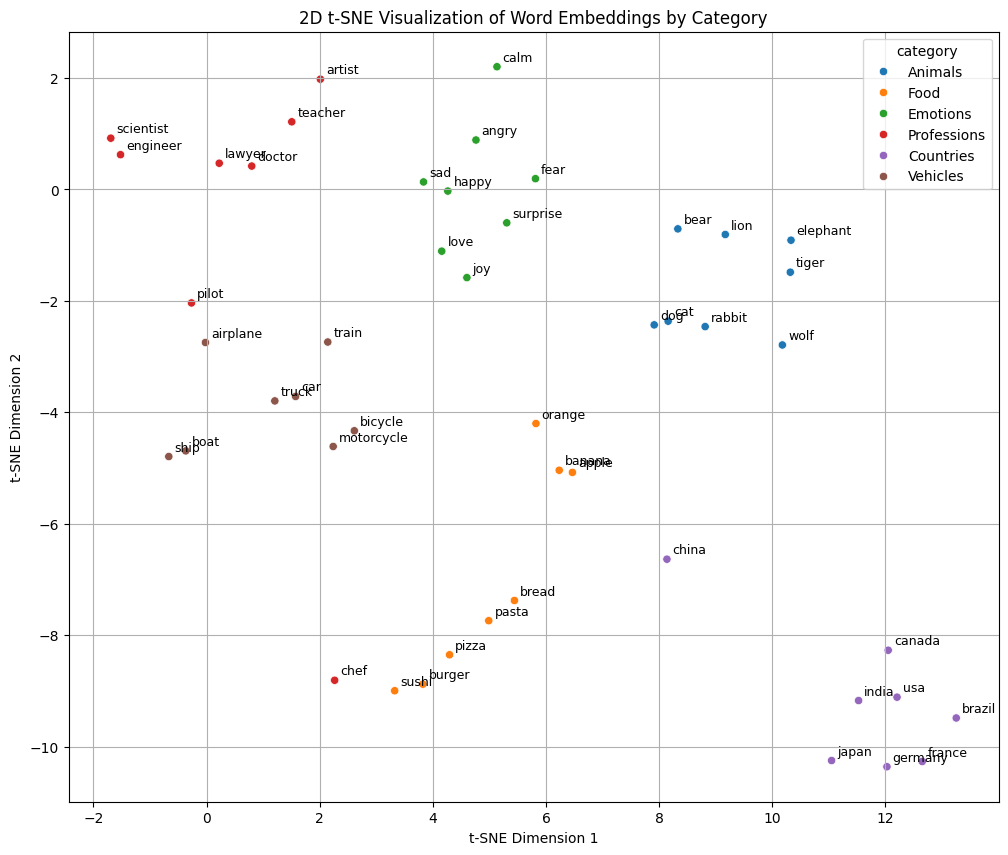

2D t-SNE visualization generated successfully.


In [7]:
print("Generating 2D t-SNE visualization of word embeddings...")

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    hue='category', # Color points by category
    data=df_word_embeddings,
    legend='full',
    palette='tab10' # Use a distinct color palette
)

# Annotate each point with the corresponding word
for i, row in df_word_embeddings.iterrows():
    plt.annotate(row['word'], (row['tsne_x'] + 0.1, row['tsne_y'] + 0.1), fontsize=9)

plt.title('2D t-SNE Visualization of Word Embeddings by Category')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

print("2D t-SNE visualization generated successfully.")

###**OBSERVATION:**
Based on the 2D t-SNE visualization of the word embeddings, clear clusters are formed according to semantic categories such as animals, food, emotions, professions, countries, and vehicles. Words belonging to the same category are positioned close to each other, showing that the embedding model captures meaningful relationships. For example, animal words like dog, cat, lion, and tiger appear grouped together, indicating strong semantic similarity. Similarly, food-related words such as apple, banana, pizza, and burger form their own cluster.
Emotion words like happy, sad, joy, and love are also placed near one another, reflecting their related meanings. Countries such as india, china, france, and germany are located close together, forming a geographic cluster. Vehicle words like car, truck, train, and airplane also appear grouped due to contextual similarity in usage.
Some interesting observations include slight overlaps between related categories, such as chef appearing closer to food-related words because of contextual association. Overall, the visualization demonstrates that semantically similar words are positioned near each other, while unrelated categories are clearly separated in the 2D space. This confirms that the Word2Vec embeddings effectively capture contextual and semantic relationships between words.


###**LAB REPORT:**

**1.	Objective**

The objective of this experiment is to understand how high-dimensional word embeddings can be visualized using dimensionality reduction techniques. In this lab, we loaded a pre-trained Word2Vec embedding model, extracted vector representations of selected words, reduced 300-dimensional vectors into 2 dimensions using t-SNE, visualized the results, and interpreted the clusters formed. This experiment helps us understand how machine learning models represent semantic meaning numerically.

**2.	Description of the Embedding Model**

In this experiment, we used the Word2Vec pre-trained model called word2vec-google-news-300. This model was trained on the Google News dataset containing billions of words.
Key details:
Model name: word2vec-google-news-300
Vector size: 300 dimensions
Vocabulary size: approximately 3 million words
Word2Vec is a neural network-based model that converts words into dense numerical vectors. Each word is represented by 300 numbers. Words that appear in similar contexts have similar vector representations. For example, relationships like king minus man plus woman approximately equals queen can be captured mathematically using these vectors.

**3.	Word List Used in the Experiment**

We selected 48 words divided into six semantic categories.
Animals: dog, cat, elephant, lion, tiger, wolf, bear, rabbit
Food: apple, banana, orange, pizza, sushi, burger, pasta, bread
Emotions: happy, sad, angry, joy, fear, love, calm, surprise
Professions: doctor, engineer, teacher, artist, scientist, chef, lawyer, pilot
Countries: usa, canada, germany, france, japan, china, india, brazil
Vehicles: car, truck, bicycle, motorcycle, airplane, train, boat, ship
These words were selected to observe whether semantically similar words form clusters.

**4.	t-SNE Visualization Result**

To visualize the 300-dimensional vectors, we used t-distributed Stochastic Neighbor Embedding (t-SNE). This algorithm reduces high-dimensional data into two dimensions while preserving similarity between nearby points.
Each word vector was reduced from 300 dimensions to 2 dimensions. The words were then plotted on a 2D graph and colored according to their category.
The visualization showed clear clusters. Animals were grouped together. Food words formed another cluster. Emotions appeared close to each other. Countries were positioned near other country names. Vehicles formed their own cluster. Professions also grouped together, with slight overlap in related areas.

**5.	Interpretation of Clusters**

The animals cluster showed that words like dog, cat, lion, and tiger were positioned close to one another. This indicates strong contextual similarity.
The food cluster contained apple, banana, pizza, burger, and other food items grouped together.
Emotion words such as happy, joy, love, and sad were located near each other, reflecting semantic similarity.
Countries such as india, china, france, and germany were positioned in the same region of the plot.
Vehicles like car, truck, train, and airplane formed another clear cluster.
Some interesting observations were noticed. The word chef appeared slightly closer to food words because chefs are strongly associated with food. Similarly, airplane and pilot appeared close due to contextual relationships.
Overall, semantically similar words were positioned near each other, showing that the embedding model successfully captures contextual meaning.

6.  **Conclusion**

This experiment demonstrated how word embeddings represent semantic meaning numerically and how t-SNE helps visualize high-dimensional data.
Word2Vec represents words as 300-dimensional vectors. Similar words have similar vector values. Since humans cannot visualize 300 dimensions, t-SNE reduces the data into 2 dimensions while preserving local similarity. The resulting visualization showed meaningful clusters corresponding to semantic categories.
Therefore, embedding visualization helps us better understand how machine learning models interpret language.
Questions Students Must Answer
1.	What problem does t-SNE solve?
t-SNE solves the problem of visualizing high-dimensional data. It reduces data from many dimensions into two or three dimensions while preserving similarity between nearby points.
2.	Why can’t we directly visualize 300-dimensional vectors?
Humans can only visually perceive up to three dimensions. A 300-dimensional vector exists in mathematical space and cannot be directly plotted or understood visually.
3.	How does t-SNE help understand embeddings?
t-SNE places similar vectors close together in two-dimensional space. This allows us to visually observe clusters, detect relationships, and understand how the embedding model groups words.
4.	Why do similar words appear together in the plot?
In Word2Vec, words that appear in similar contexts have similar numerical representations. Since t-SNE preserves local similarity, these words are placed close to each other in the visualization.
5.	Why might some unrelated words appear close?
t-SNE preserves local structure but may distort global relationships. Some words may share partial contextual overlap. Also, parameter choices like perplexity can influence placement.
6.	Give two real-world uses of embedding visualization.
One use is evaluating NLP models to check whether semantic relationships are learned correctly.
Another use is detecting bias in AI systems by observing how different words cluster together.


